# First Learned Global Forecasting Model
This controlled experiment tests whether one lightweight global `HistGradientBoostingRegressor` improves on the frozen baselines for all 70 department-store series. A horizon-conditioned direct formulation produces every horizon without recursively consuming validation actuals. **No lockbox targets, prices, tuning, or series exclusions are used.**

## Predeclared construction and interpretation
Each supervised row represents `(series, origin T, horizon h, target day T+h)`. Origins are sampled weekly, aligned backward from `training_end - 28`, with `T >= 56`; this rule was fixed before performance inspection. Lags and rolling values end at T. Calendar fields describe T+h and are scheduled fields. A model is promising if overall macro RMSSE is below the frozen 1.06690 benchmark, but fold stability, seasonal naïve, WAPE, bias, and series regressions remain mandatory context.

In [1]:
from pathlib import Path
import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))
from marketmind.forecasting.dataset import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, build_prediction_table, build_training_table, prepare_calendar, weekly_training_origins
from marketmind.forecasting.metrics import rmsse, mae
DAYS=[f'd_{i}' for i in range(1,1914)]
FOLDS=[(1,1465,1466,1493),(2,1549,1550,1577),(3,1633,1634,1661),(4,1717,1718,1745),(5,1801,1802,1829),(6,1885,1886,1913)]
MODEL_PARAMS=dict(loss='squared_error',learning_rate=.05,max_iter=120,max_leaf_nodes=31,max_depth=None,min_samples_leaf=100,l2_regularization=1.0,early_stopping=False,random_state=42)
assert len(FOLDS)==6 and all(e-s+1==28 for _,_,s,e in FOLDS) and max(e for *_,e in FOLDS)==1913

## Data and exact feature set
Historical features are `lag_1/7/14/28/56` and origin-anchored mean/standard deviation over 7/28/56 days. Target-date numeric context is horizon, weekday, day of month, month, year, day index, and state SNAP. Categoricals are store, department, state, primary event name, and primary event type. Fold-local ordinal encoding uses an explicit unknown code; there is no target encoding. Prices are excluded.

In [2]:
sales=pd.read_csv(ROOT/'data/raw/m5/sales_train_validation.csv',usecols=['dept_id','store_id','state_id',*DAYS])
calendar=prepare_calendar(pd.read_csv(ROOT/'data/raw/m5/calendar.csv'))
core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[DAYS].sum().reset_index()
values=core[DAYS].to_numpy(dtype=np.float32)
series=core[['state_id','store_id','dept_id']]
assert len(core)==70 and series[['store_id','dept_id']].drop_duplicates().shape[0]==70
assert calendar.loc[1913,'d']=='d_1913'
len(core), values.shape

/var/folders/qr/5t89y2n92z12ddb73k2_ybdm0000gn/T/ipykernel_61447/1385247843.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  core=sales.groupby(['state_id','store_id','dept_id'],sort=True,observed=True)[DAYS].sum().reset_index()


(70, (70, 1913))

## Fold-local training and evaluation
For each fold, the encoder is fitted only on that fold's generated training table. Validation features are constructed from the truncated training history and known target-date calendar. Assertions verify training targets end by the cutoff, predictions contain 70×28 rows, and no negative prediction survives clipping. RMSSE scales use the fold training history only.

In [3]:
def baselines(train):
    return {'historical_mean_28':np.repeat(train[:,-28:].mean(1)[:,None],28,axis=1), 'seasonal_naive_7':np.tile(train[:,-7:],(1,4)), 'last_value':np.repeat(train[:,-1,None],28,axis=1)}
def encode_fit(X):
    enc=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,encoded_missing_value=-1,dtype=np.float32)
    cats=enc.fit_transform(X[CATEGORICAL_COLUMNS])
    return enc,np.column_stack([cats,X[NUMERIC_COLUMNS].to_numpy(np.float32)])
def encode_apply(enc,X): return np.column_stack([enc.transform(X[CATEGORICAL_COLUMNS]),X[NUMERIC_COLUMNS].to_numpy(np.float32)])
metric_rows=[]; prediction_rows=[]; build_stats=[]
for fold,train_end,val_start,val_end in FOLDS:
    origins=weekly_training_origins(train_end)
    assert origins[-1]+28==train_end and np.all(origins+28<=train_end)
    started=time.perf_counter(); X_train,y_train=build_training_table(series,values,calendar,origins); build_seconds=time.perf_counter()-started
    memory_mb=(X_train.memory_usage(deep=True).sum()+y_train.nbytes)/1024**2
    encoder,X_encoded=encode_fit(X_train)
    model=HistGradientBoostingRegressor(categorical_features=list(range(len(CATEGORICAL_COLUMNS))),**MODEL_PARAMS)
    fit_started=time.perf_counter(); model.fit(X_encoded,y_train); fit_seconds=time.perf_counter()-fit_started
    train_values=values[:,:train_end]
    X_valid=build_prediction_table(series,train_values,calendar,train_end)
    raw_prediction=model.predict(encode_apply(encoder,X_valid)).reshape(70,28)
    negative_count=int((raw_prediction<0).sum()); prediction=np.clip(raw_prediction,0,None)
    actual=values[:,val_start-1:val_end]
    assert prediction.shape==actual.shape==(70,28) and not (prediction<0).any()
    candidates={'global_hgbr':prediction,**baselines(train_values)}
    for name,forecast in candidates.items():
        for i,row in series.reset_index(drop=True).iterrows():
            metric_rows.append({**row.to_dict(),'fold':fold,'model':name,'rmsse':rmsse(actual[i],forecast[i],train_values[i]),'mae':mae(actual[i],forecast[i]),'absolute_error':np.abs(actual[i]-forecast[i]).sum(),'signed_error':(forecast[i]-actual[i]).sum(),'actual_total':actual[i].sum()})
    for i,row in series.reset_index(drop=True).iterrows():
        for h in range(28): prediction_rows.append({**row.to_dict(),'fold':fold,'horizon':h+1,'actual':actual[i,h],'forecast':prediction[i,h],'error':prediction[i,h]-actual[i,h]})
    build_stats.append({'fold':fold,'origins':len(origins),'training_rows':len(X_train),'memory_mb':memory_mb,'build_seconds':build_seconds,'fit_seconds':fit_seconds,'negative_predictions':negative_count,'prediction_count':raw_prediction.size})
    print(f'fold {fold}: {len(X_train):,} rows, {memory_mb:.1f} MB, build {build_seconds:.2f}s, fit {fit_seconds:.2f}s, negatives {negative_count}')
results=pd.DataFrame(metric_rows); predictions=pd.DataFrame(prediction_rows); build_stats=pd.DataFrame(build_stats)
build_stats

fold 1: 388,080 rows, 120.5 MB, build 3.45s, fit 3.27s, negatives 0


fold 2: 411,600 rows, 127.8 MB, build 3.65s, fit 3.17s, negatives 0


fold 3: 435,120 rows, 135.1 MB, build 3.83s, fit 3.34s, negatives 0


fold 4: 458,640 rows, 142.4 MB, build 4.18s, fit 3.51s, negatives 0


fold 5: 482,160 rows, 149.7 MB, build 4.32s, fit 3.58s, negatives 0


fold 6: 505,680 rows, 157.1 MB, build 4.41s, fit 3.77s, negatives 0


,fold,origins,training_rows,memory_mb,build_seconds,fit_seconds,negative_predictions,prediction_count
0,1,198,388080,120.519506,3.452622,3.269046,0,1960
1,2,210,411600,127.832558,3.654051,3.173230,0,1960
2,3,222,435120,135.145342,3.832408,3.339847,0,1960
3,4,234,458640,142.436363,4.183687,3.507296,0,1960
4,5,246,482160,149.736263,4.318565,3.578142,0,1960
5,6,258,505680,157.050583,4.413894,3.768139,0,1960


In [4]:
summary=results.groupby('model').agg(macro_rmsse=('rmsse','mean'),macro_mae=('mae','mean'),absolute_error=('absolute_error','sum'),actual_total=('actual_total','sum'),signed_error=('signed_error','sum')).reset_index()
summary['pooled_wape']=summary.absolute_error/summary.actual_total
summary['pooled_bias']=summary.signed_error/summary.actual_total
summary['absolute_improvement_vs_mean']=1.06690-summary.macro_rmsse
summary['relative_improvement_vs_mean_pct']=100*summary.absolute_improvement_vs_mean/1.06690
summary.drop(columns=['absolute_error','actual_total','signed_error']).sort_values('macro_rmsse')

,model,macro_rmsse,macro_mae,pooled_wape,pooled_bias,absolute_improvement_vs_mean,relative_improvement_vs_mean_pct
0,global_hgbr,0.779160,59.191994,0.106173,-0.011165,0.287740,26.969759
1,historical_mean_28,1.066903,99.422145,0.178333,-0.018127,-0.000003,-0.000250
3,seasonal_naive_7,1.069671,91.484864,0.164096,-0.010948,-0.002771,-0.259721
2,last_value,1.532226,162.153231,0.290854,0.161543,-0.465326,-43.614767


In [5]:
fold_summary=results.groupby(['fold','model']).agg(macro_rmsse=('rmsse','mean'),macro_mae=('mae','mean'),absolute_error=('absolute_error','sum'),actual_total=('actual_total','sum'),signed_error=('signed_error','sum')).reset_index()
fold_summary['pooled_wape']=fold_summary.absolute_error/fold_summary.actual_total
fold_summary['pooled_bias']=fold_summary.signed_error/fold_summary.actual_total
fold_summary.drop(columns=['absolute_error','actual_total','signed_error'])

,fold,model,macro_rmsse,macro_mae,pooled_wape,pooled_bias
0,1,global_hgbr,0.865964,63.994646,0.120992,-0.028667
1,1,historical_mean_28,1.134867,100.686188,0.190363,-0.057872
2,1,last_value,1.805146,194.695918,0.368103,0.090773
3,1,seasonal_naive_7,1.215038,103.727551,0.196113,-0.061568
4,2,global_hgbr,0.681096,49.801777,0.094852,-0.009675
5,2,historical_mean_28,0.914865,85.892201,0.163589,0.004642
6,2,last_value,1.329799,133.871939,0.254971,0.181009
7,2,seasonal_naive_7,0.928540,71.967857,0.137069,-0.044549
8,3,global_hgbr,0.670789,51.595235,0.089647,0.000136
9,3,historical_mean_28,0.945059,91.600765,0.159157,-0.015099


## Series, group, and horizon error analysis
All 70 series remain in evaluation. Improvements/regressions compare six-fold per-series RMSSE with the official historical-mean baseline. Horizon summaries use pooled MAE and signed error; horizon RMSSE is not reported because RMSSE scaling is series/fold-specific.

In [6]:
series_scores=results.groupby(['state_id','store_id','dept_id','model']).rmsse.mean().unstack('model')
series_scores['improvement_vs_mean']=series_scores.historical_mean_28-series_scores.global_hgbr
display(series_scores.sort_values('global_hgbr').head(10))
display(series_scores.sort_values('global_hgbr').tail(10))
display(series_scores.sort_values('improvement_vs_mean',ascending=False).head(10))
display(series_scores.sort_values('improvement_vs_mean').head(10))
learned=results[results.model=='global_hgbr']
for group in ['dept_id','store_id','state_id']:
    display(learned.groupby(group).rmsse.mean().sort_values().rename('macro_rmsse').to_frame())

model                          global_hgbr  historical_mean_28  last_value  \
state_id store_id dept_id                                                    
TX       TX_2     FOODS_3         0.371789            0.784144    1.479663   
WI       WI_3     FOODS_3         0.413798            0.889636    1.268533   
TX       TX_1     FOODS_3         0.430974            0.778626    1.795930   
CA       CA_1     FOODS_3         0.435211            0.980872    1.605420   
TX       TX_3     FOODS_3         0.477365            0.864404    1.574689   
         TX_2     FOODS_2         0.492171            0.772681    1.004290   
                  HOUSEHOLD_1     0.518232            0.987999    1.356358   
CA       CA_2     HOUSEHOLD_1     0.528216            1.177235    2.012651   
TX       TX_1     FOODS_2         0.529257            0.810221    1.571745   
WI       WI_2     FOODS_3         0.529327            1.062437    1.416434   

model                          seasonal_naive_7  improvement_vs_mean  
state_id store_id dept_id                                             
TX       TX_2     FOODS_3              0.602633             0.412355  
WI       WI_3     FOODS_3              0.934372             0.475838  
TX       TX_1     FOODS_3              0.730098             0.347651  
CA       CA_1     FOODS_3              0.692224             0.545661  
TX       TX_3     FOODS_3              0.851663             0.387039  
         TX_2     FOODS_2              0.732055             0.280510  
                  HOUSEHOLD_1          0.734494             0.469766  
CA       CA_2     HOUSEHOLD_1          0.548977             0.649019  
TX       TX_1     FOODS_2              0.889013             0.280963  
WI       WI_2     FOODS_3              1.358063             0.533110

model                          global_hgbr  historical_mean_28  last_value  \
state_id store_id dept_id                                                    
TX       TX_3     FOODS_1         1.056573            1.002242    1.357720   
         TX_1     FOODS_1         1.057163            1.145624    1.756925   
WI       WI_2     FOODS_2         1.057673            1.636964    2.306883   
                  HOUSEHOLD_1     1.087919            1.445382    1.651136   
CA       CA_3     HOBBIES_2       1.174590            1.102889    1.414187   
TX       TX_3     HOBBIES_2       1.219629            1.269887    1.560613   
WI       WI_2     HOBBIES_2       1.233311            1.149795    1.382800   
TX       TX_1     HOBBIES_2       1.380340            1.375949    1.897136   
CA       CA_2     FOODS_2         1.487787            2.208956    3.884881   
         CA_4     HOBBIES_2       1.623835            1.086864    1.167588   

model                          seasonal_naive_7  improvement_vs_mean  
state_id store_id dept_id                                             
TX       TX_3     FOODS_1              1.338823            -0.054331  
         TX_1     FOODS_1              1.279599             0.088461  
WI       WI_2     FOODS_2              2.264117             0.579291  
                  HOUSEHOLD_1          1.579941             0.357463  
CA       CA_3     HOBBIES_2            1.203566            -0.071700  
TX       TX_3     HOBBIES_2            1.314298             0.050258  
WI       WI_2     HOBBIES_2            1.304477            -0.083516  
TX       TX_1     HOBBIES_2            1.829961            -0.004391  
CA       CA_2     FOODS_2              1.469877             0.721169  
         CA_4     HOBBIES_2            1.308480            -0.536971

model                          global_hgbr  historical_mean_28  last_value  \
state_id store_id dept_id                                                    
CA       CA_2     FOODS_2         1.487787            2.208956    3.884881   
         CA_3     HOUSEHOLD_1     0.696041            1.388674    1.732816   
         CA_1     HOUSEHOLD_1     0.620211            1.290884    2.144751   
         CA_2     FOODS_3         0.575744            1.240976    2.123779   
WI       WI_1     HOUSEHOLD_1     0.626423            1.281369    1.875455   
CA       CA_2     HOUSEHOLD_1     0.528216            1.177235    2.012651   
WI       WI_1     FOODS_2         0.855290            1.487297    2.349092   
         WI_2     FOODS_2         1.057673            1.636964    2.306883   
         WI_1     FOODS_3         0.542962            1.121547    1.652057   
CA       CA_2     HOUSEHOLD_2     0.563587            1.138160    1.740702   

model                          seasonal_naive_7  improvement_vs_mean  
state_id store_id dept_id                                             
CA       CA_2     FOODS_2              1.469877             0.721169  
         CA_3     HOUSEHOLD_1          0.880429             0.692633  
         CA_1     HOUSEHOLD_1          0.737948             0.670673  
         CA_2     FOODS_3              0.713955             0.665232  
WI       WI_1     HOUSEHOLD_1          1.047967             0.654947  
CA       CA_2     HOUSEHOLD_1          0.548977             0.649019  
WI       WI_1     FOODS_2              1.510299             0.632007  
         WI_2     FOODS_2              2.264117             0.579291  
         WI_1     FOODS_3              1.026358             0.578584  
CA       CA_2     HOUSEHOLD_2          0.535255             0.574572

model                        global_hgbr  historical_mean_28  last_value  \
state_id store_id dept_id                                                  
CA       CA_4     HOBBIES_2     1.623835            1.086864    1.167588   
WI       WI_2     HOBBIES_2     1.233311            1.149795    1.382800   
CA       CA_3     HOBBIES_2     1.174590            1.102889    1.414187   
TX       TX_3     FOODS_1       1.056573            1.002242    1.357720   
CA       CA_4     HOBBIES_1     0.890291            0.868978    0.950860   
TX       TX_1     HOBBIES_2     1.380340            1.375949    1.897136   
         TX_2     FOODS_1       0.778156            0.785566    1.448180   
                  HOBBIES_2     0.946888            0.960458    1.270669   
WI       WI_3     HOBBIES_2     1.033894            1.052211    1.230770   
         WI_1     HOBBIES_2     1.003841            1.024829    1.232412   

model                        seasonal_naive_7  improvement_vs_mean  
state_id store_id dept_id                                           
CA       CA_4     HOBBIES_2          1.308480            -0.536971  
WI       WI_2     HOBBIES_2          1.304477            -0.083516  
CA       CA_3     HOBBIES_2          1.203566            -0.071700  
TX       TX_3     FOODS_1            1.338823            -0.054331  
CA       CA_4     HOBBIES_1          1.200742            -0.021313  
TX       TX_1     HOBBIES_2          1.829961            -0.004391  
         TX_2     FOODS_1            1.105136             0.007410  
                  HOBBIES_2          1.177533             0.013570  
WI       WI_3     HOBBIES_2          1.319768             0.018317  
         WI_1     HOBBIES_2          1.237216             0.020988

,macro_rmsse
dept_id,
FOODS_3,0.517273
HOBBIES_1,0.682508
HOUSEHOLD_1,0.694953
HOUSEHOLD_2,0.729660
FOODS_2,0.769446
FOODS_1,0.889997
HOBBIES_2,1.170281


,macro_rmsse
store_id,
TX_2,0.647328
CA_1,0.698682
WI_1,0.723598
WI_3,0.727927
TX_1,0.765714
CA_2,0.776534
CA_3,0.783590
TX_3,0.809456
CA_4,0.918309


,macro_rmsse
state_id,
TX,0.740833
CA,0.794279
WI,0.797328


,horizon,mae,wape,bias
0,1,49.109140,0.093342,-0.021805
1,2,45.245914,0.092188,-0.002933
2,3,51.454806,0.110640,0.036741
3,4,48.655916,0.099022,-0.004980
4,5,56.302550,0.098892,-0.015938
5,6,72.301698,0.103331,-0.038870
6,7,68.291055,0.096974,-0.035953
7,8,59.315596,0.109664,-0.042560
8,9,51.049461,0.101415,-0.025151
9,10,50.013837,0.101789,0.004100


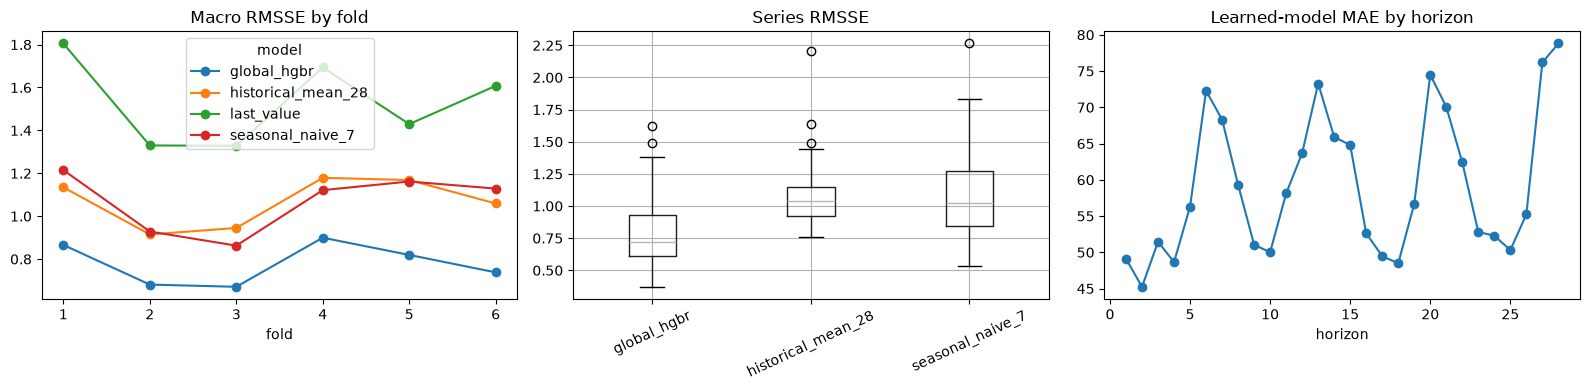

In [7]:
horizon=predictions.groupby('horizon').agg(mae=('error',lambda x:x.abs().mean()),mean_error=('error','mean'),absolute_error=('error',lambda x:x.abs().sum()),actual_total=('actual','sum'),signed_error=('error','sum')).reset_index()
horizon['wape']=horizon.absolute_error/horizon.actual_total
horizon['bias']=horizon.signed_error/horizon.actual_total
display(horizon[['horizon','mae','wape','bias']])
fig,axes=plt.subplots(1,3,figsize=(16,4))
fold_summary.pivot(index='fold',columns='model',values='macro_rmsse').plot(marker='o',ax=axes[0],title='Macro RMSSE by fold')
series_scores[['global_hgbr','historical_mean_28','seasonal_naive_7']].boxplot(ax=axes[1]); axes[1].tick_params(axis='x',rotation=25); axes[1].set_title('Series RMSSE')
horizon.plot(x='horizon',y='mae',marker='o',ax=axes[2],title='Learned-model MAE by horizon',legend=False)
plt.tight_layout(); plt.show()

## Limitations and next-decision boundary
This is one untuned configuration with weekly sampled origins, raw unit targets, limited calendar context, ordinal categorical encoding, and no prices. Any improvement must be interpreted through folds, series, horizons, WAPE, and bias. The final model family is not frozen and the lockbox remains untouched.